In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('../data/processed/inventory_ready_for_model.csv')

In [17]:
# Definir Features (X) y Target (y)
X = df.drop(columns=['stockout_risk'])
y = df['stockout_risk']

# Dividir los datos (80% entrenamiento, 20% prueba)
# Usamos stratify=y para mantener la proporción de riesgo en ambos grupos. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"train: {X_train.shape[0]} filas")
print(f"test: {X_test.shape[0]} filas")

train: 2240 filas
test: 560 filas


#Utilizamos stratify, porque al ser lo más normal que no haya rotura de stock, nos puede salir siempre no. Con esto, lo evitamos.

__MODELO DE REGRESION LOGISTICA__

In [5]:
#  Entrenamos el modelo
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86       422
           1       0.00      0.00      0.00       138

    accuracy                           0.75       560
   macro avg       0.38      0.50      0.43       560
weighted avg       0.57      0.75      0.65       560



c:\Users\uebne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\uebne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\uebne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

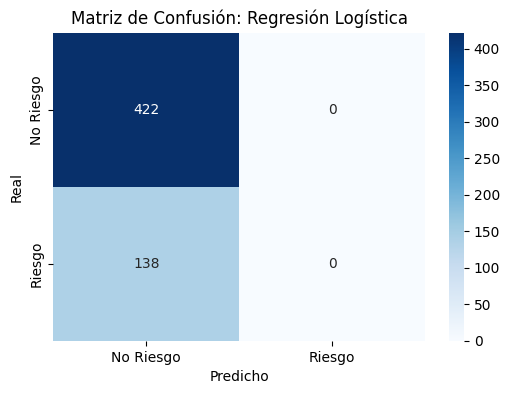

In [6]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Riesgo', 'Riesgo'], yticklabels=['No Riesgo', 'Riesgo'])
plt.title('Matriz de Confusión: Regresión Logística')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

El modelo ha decidido, por precaución o porque no ha encontrado patrones claros, etiquetar absolutamente todo como "No Riesgo".

Ha acertado en 422 casos (los que realmente no tenían riesgo), pero ha fallado en los 138 casos donde sí había riesgo real, clasificándolos como "No Riesgo".

In [8]:
#balanceo los datos
model = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.45      0.56       422
           1       0.22      0.48      0.30       138

    accuracy                           0.46       560
   macro avg       0.48      0.47      0.43       560
weighted avg       0.60      0.46      0.50       560



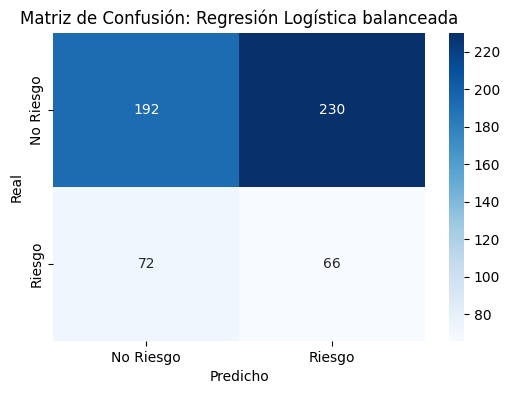

In [18]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Riesgo', 'Riesgo'], yticklabels=['No Riesgo', 'Riesgo'])
plt.title('Matriz de Confusión: Regresión Logística balanceada')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

C:\Users\uebne\AppData\Local\Temp\ipykernel_9360\2669921940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=coef_df, palette='viridis')


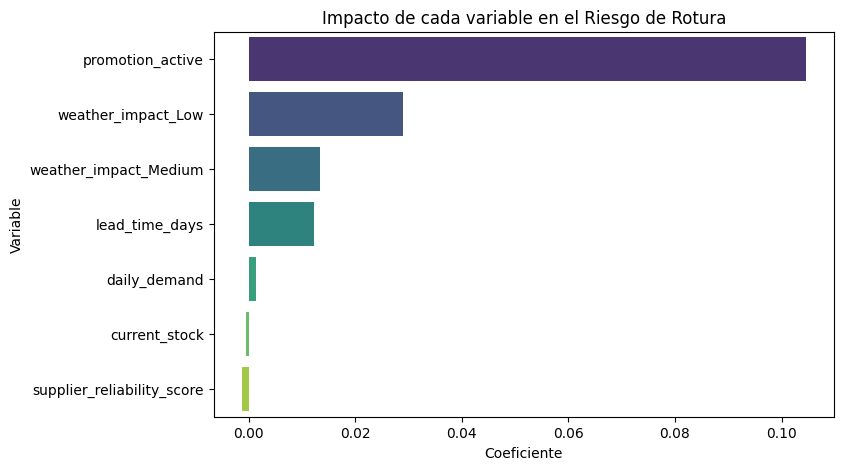

In [10]:
# 4. Gráfico de Coeficientes (Importancia de variables)
# Esto muestra qué variables influyen más en el riesgo (según el modelo)
coef_df = pd.DataFrame({'Variable': X.columns, 'Coeficiente': model.coef_[0]})
coef_df = coef_df.sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coeficiente', y='Variable', data=coef_df, palette='viridis')
plt.title('Impacto de cada variable en el Riesgo de Rotura')
plt.show()

Vamos a hacer un escalado. Esto pondrá todas tus variables en el mismo rango (de 0 a 1) para que el modelo pueda ver las diferencias reales.

In [11]:
from sklearn.preprocessing import StandardScaler

# Escalamos los datos 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Seleccionamos un caso real del conjunto de prueba (por ejemplo, la primera fila)
ejemplo = X_test.iloc[[0]] 

# Pedimos al modelo que lo prediga
prediccion = model.predict(ejemplo)
probabilidad = model.predict_proba(ejemplo)

# Mostramos el resultado 
estado = "Riesgo de Rotura" if prediccion[0] == 1 else "Stock Seguro"
print(f"Datos del producto: \n{ejemplo.to_string(index=False)}")
print(f"\nPredicción del modelo: {estado}")
print(f"Confianza del modelo: {probabilidad[0][prediccion[0]]*100:.2f}%")

Datos del producto: 
 current_stock  daily_demand  lead_time_days  supplier_reliability_score  promotion_active  weather_impact_Low  weather_impact_Medium
           215            22              14                          73                 0                True                  False

Predicción del modelo: Riesgo de Rotura
Confianza del modelo: 50.72%


VAMOS A EJECUTAR EL MODELO A VER COMO NOS DA PONIENDO NOSOTROS LOS DATOS

In [ ]:
import joblib

# Cargar el modelo
model = joblib.load(r'C:\Users\uebne\Desktop\Bootcamp\Apuntes_Eduardo\2-Data_analysis\3-Machine_Learning\Proyecto_M_L_Eduardo\models\trained_model.pkl')

# Definir los valores de prueba
current_stock = 100
daily_demand = 287
lead_time_days = 20
supplier_reliability_score = 0.9
promotion_active = 0
weather_impact_Low = 0    # Valor 0 o 1
weather_impact_Medium = 0 # Valor 0 o 1

# Crear el DataFrame 
datos_demo = pd.DataFrame([[
    current_stock, daily_demand, lead_time_days, 
    supplier_reliability_score, promotion_active, 
    weather_impact_Low, weather_impact_Medium
]], columns=['current_stock', 'daily_demand', 'lead_time_days', 
             'supplier_reliability_score', 'promotion_active', 
             'weather_impact_Low', 'weather_impact_Medium'])

# Realizar la predicción
probabilidad = model.predict_proba(datos_demo)[0][1]
prediccion = model.predict(datos_demo)[0]

# Resultado
print(f"--- RESULTADO ---")
print(f"Estado: {' Riesgo Alto' if prediccion == 1 else 'Nivel Seguro'}")
print(f"Probabilidad de rotura: {probabilidad:.2%}")

--- RESULTADO ---
Estado:  Riesgo Alto
Probabilidad de rotura: 55.97%
